# GraphSAGE Only - Undirected Structural Branch

This notebook retrains the GraphSAGE-only structural baseline on the eval-3 branch.

Differences from the earlier `graphSAGE.ipynb`:

- uses the undirected structural split from `cache/node2vec-2/undirected_split.pkl`
- keeps eval-3 test edges untouched for downstream comparison
- creates a separate validation split from train edges for early stopping
- saves eval-3-specific artifacts for `eval-3.ipynb`


In [1]:
import os, random, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

REPO_ROOT = r'C:\\programming\\github-repos\\graph-ending'
CACHE_DIR = os.path.join(REPO_ROOT, 'WikiCS', 'custom-wiki', 'cache', 'eval-3')
PHASE0_CACHE = os.path.join(REPO_ROOT, 'WikiCS', 'custom-wiki', 'cache', 'node2vec-2')
os.makedirs(CACHE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VAL_RATIO = 0.1
print(f'Device: {device}')


Device: cpu


## Step 1 - Load Eval-3 Structural Graph and Build Validation Split


In [2]:
with open(os.path.join(PHASE0_CACHE, 'undirected_split.pkl'), 'rb') as f:
    split_data = pickle.load(f)

G_train_full = split_data['G_train_struct']
E_test = split_data['E_test']

all_train_edges = list(G_train_full.edges())
random.shuffle(all_train_edges)
n_val = max(1, int(np.ceil(VAL_RATIO * len(all_train_edges))))

val_edges = all_train_edges[:n_val]
message_edges = all_train_edges[n_val:]

G_message = G_train_full.__class__()
G_message.add_nodes_from(G_train_full.nodes())
G_message.add_edges_from(message_edges)

valid_nodes = list(G_message.nodes())
node_to_idx = {int(n): i for i, n in enumerate(valid_nodes)}
idx_to_node = {i: int(n) for n, i in node_to_idx.items()}
N = len(valid_nodes)

train_edges_idx = [(node_to_idx[int(u)], node_to_idx[int(v)]) for u, v in G_message.edges()]
edge_index = torch.tensor(train_edges_idx, dtype=torch.long).t().contiguous()

val_pos_edges = [(node_to_idx[int(u)], node_to_idx[int(v)]) for u, v in val_edges if int(u) in node_to_idx and int(v) in node_to_idx]
val_pos_edge_index = torch.tensor(val_pos_edges, dtype=torch.long).t().contiguous()

test_pos_edges = [(node_to_idx[int(u)], node_to_idx[int(v)]) for u, v in E_test if int(u) in node_to_idx and int(v) in node_to_idx]
test_pos_edge_index = torch.tensor(test_pos_edges, dtype=torch.long).t().contiguous()

print(f'Nodes: {N}')
print(f'Message-passing train edges: {edge_index.size(1)}')
print(f'Validation positive edges : {val_pos_edge_index.size(1)}')
print(f'Eval-3 test positive edges: {test_pos_edge_index.size(1)}')


Nodes: 11701
Message-passing train edges: 155610
Validation positive edges : 17290
Eval-3 test positive edges: 43223


## Step 2 - Define Model


In [3]:
class GraphSAGELinkPredictor(torch.nn.Module):
    def __init__(self, num_nodes, embedding_dim, hidden_channels, out_channels):
        super().__init__()
        self.node_embeddings = torch.nn.Embedding(num_nodes, embedding_dim)
        torch.nn.init.xavier_uniform_(self.node_embeddings.weight)
        self.conv1 = SAGEConv(embedding_dim, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def encode(self):
        return self.node_embeddings.weight

    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM = 64, 128, 64
model = GraphSAGELinkPredictor(N, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

edge_index = edge_index.to(device)
val_pos_edge_index = val_pos_edge_index.to(device)
test_pos_edge_index = test_pos_edge_index.to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 781,824


## Step 3 - Training Loop


In [4]:
def train_step():
    model.train()
    optimizer.zero_grad()
    z = model(model.encode(), edge_index)
    neg_edge_index = negative_sampling(edge_index, num_nodes=N, num_neg_samples=edge_index.size(1))
    pos_scores = model.decode(z, edge_index)
    neg_scores = model.decode(z, neg_edge_index)
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()
    return loss.item()

def auc_on_positive_edges(pos_edge_index):
    model.eval()
    with torch.no_grad():
        z = model(model.encode(), edge_index)
        neg_edge_index = negative_sampling(pos_edge_index, num_nodes=N, num_neg_samples=pos_edge_index.size(1))
        pos_scores = torch.sigmoid(model.decode(z, pos_edge_index)).cpu().numpy()
        neg_scores = torch.sigmoid(model.decode(z, neg_edge_index)).cpu().numpy()
        scores = np.concatenate([pos_scores, neg_scores])
        labels = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
        return roc_auc_score(labels, scores)

patience, best_val_auc, epochs_no_improve = 15, 0.0, 0
max_epochs = 200
train_losses, val_aucs = [], []

print('Training GraphSAGE Only on eval-3 branch...')
print('-' * 55)

for epoch in range(1, max_epochs + 1):
    loss = train_step()
    train_losses.append(loss)
    if epoch % 5 == 0:
        val_auc = auc_on_positive_edges(val_pos_edge_index)
        val_aucs.append(val_auc)
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f}')
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

print('-' * 55)
print(f'Best Val AUC: {best_val_auc:.4f}')


Training GraphSAGE Only on eval-3 branch...
-------------------------------------------------------
Epoch   5 | Loss: 0.6729 | Val AUC: 0.8051
Epoch  10 | Loss: 0.5935 | Val AUC: 0.7500
Epoch  15 | Loss: 0.5621 | Val AUC: 0.7927
Epoch  20 | Loss: 0.5532 | Val AUC: 0.8213
Epoch  25 | Loss: 0.5458 | Val AUC: 0.8308
Epoch  30 | Loss: 0.5373 | Val AUC: 0.8455
Epoch  35 | Loss: 0.5280 | Val AUC: 0.8620
Epoch  40 | Loss: 0.5259 | Val AUC: 0.8664
Epoch  45 | Loss: 0.5198 | Val AUC: 0.8820
Epoch  50 | Loss: 0.5092 | Val AUC: 0.8858
Epoch  55 | Loss: 0.5038 | Val AUC: 0.8996
Epoch  60 | Loss: 0.5004 | Val AUC: 0.8953
Epoch  65 | Loss: 0.4929 | Val AUC: 0.8993
Epoch  70 | Loss: 0.4902 | Val AUC: 0.9025
Epoch  75 | Loss: 0.4878 | Val AUC: 0.9063
Epoch  80 | Loss: 0.4887 | Val AUC: 0.9092
Epoch  85 | Loss: 0.4878 | Val AUC: 0.9080
Epoch  90 | Loss: 0.4889 | Val AUC: 0.9058
Epoch  95 | Loss: 0.4867 | Val AUC: 0.9149
Epoch 100 | Loss: 0.4860 | Val AUC: 0.9075
Epoch 105 | Loss: 0.4839 | Val AUC: 0.90

## Step 4 - Final Evaluation and Save


Final Test AUC: 0.9190


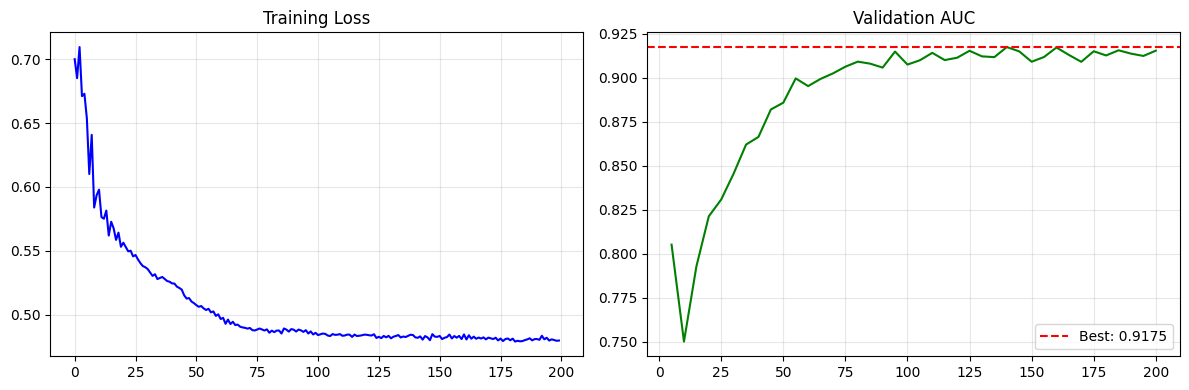

Saved to C:\\programming\\github-repos\\graph-ending\WikiCS\custom-wiki\cache\eval-3\graphsage_results_eval3.pkl


In [5]:
model.load_state_dict(best_model_state)
model.to(device)

test_auc = auc_on_positive_edges(test_pos_edge_index)
print(f'Final Test AUC: {test_auc:.4f}')

model.eval()
with torch.no_grad():
    final_embeddings = model(model.encode(), edge_index).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='blue')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(np.arange(5, len(val_aucs) * 5 + 1, 5), val_aucs, color='green')
axes[1].axhline(y=best_val_auc, color='red', linestyle='--', label=f'Best: {best_val_auc:.4f}')
axes[1].set_title('Validation AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
curve_path = os.path.join(CACHE_DIR, 'graphsage_training_curve_eval3.png')
plt.savefig(curve_path, dpi=150)
plt.show()

results = {
    'test_auc': float(test_auc),
    'best_val_auc': float(best_val_auc),
    'train_losses': train_losses,
    'val_aucs': val_aucs,
    'final_embeddings': final_embeddings,
    'node_to_idx': node_to_idx,
    'idx_to_node': idx_to_node,
    'n_nodes': N,
    'uses_bge_m3': False,
    'split_branch': 'eval-3 undirected structural branch',
    'validation_ratio_from_train': VAL_RATIO,
}

out_path = os.path.join(CACHE_DIR, 'graphsage_results_eval3.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(results, f)

print(f'Saved to {out_path}')
